In [26]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern

def GPR_Model(X, y_target_well, TI_target_well, y_other_well, TI_other_well, total_steam, LS_bounds=(1e-1, 10), nu=1.5, alpha=1e-10):
    """
    Fits a Gaussian Process Regressor on data and returns the mean and standard deviation of predictions
    :param X: 1D vector containing the x values of observed data (e.g. months)
    :param y_target_well: 1D vector containing the y values of observed data for the target well (e.g. steam flow)
    :param TI_target_well: The training indices of observations to train on for the target well.
    :param y_other_well: 1D vector containing the y values of observed data for other wells
    :param TI_other_well: The training indices of observations to train on for other wells.
    :param LS_bounds: Length scale bounds for the Matern kernel
    :param nu: Parameter for the Matern kernel
    :param alpha: Regularization parameter for GaussianProcessRegressor
    :return: mean_prediction, std_prediction
    """
    X_train, y_train = X[TI_target_well], y_target_well[TI_target_well]

    kernel = 1 * Matern(length_scale_bounds=LS_bounds, nu=nu)
    gaussian_process = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=10, alpha=alpha)

    y_additional = []
    X_additional = []
    if isinstance(TI_other_well, np.ndarray) and TI_other_well.size != 0:
        for i in range(len(y_other_well)):
            if i in TI_other_well:
                y_additional.append(total_steam[i] - y_other_well[i])
                X_additional.append(i + 1)

        # Convert additional data lists to numpy arrays
        y_additional = np.array(y_additional)
        X_additional = np.array(X_additional).reshape(-1, 1)

        # Combine the original training data with the additional data
        X_train = np.concatenate([X_train.reshape(-1, 1), X_additional])
        y_train = np.concatenate([y_train, y_additional])

    # Fit the Gaussian Process model
    gaussian_process.fit(X_train, y_train)

    # Make predictions
    mean_prediction, std_prediction = gaussian_process.predict(X.reshape(-1, 1), return_std=True)

    return mean_prediction, std_prediction

In [40]:
# Define wells data
wells_data = {
    9: {
        'months': np.linspace(start=1, stop=12, num=12).reshape(-1, 1),
        'y': np.array([19.42, 19.94, 19.92, 19.96, 20.03, 20.13, 20.25, 20.42, 20.63, 20.9, 21.25, 21.76]),
        'training_indices': [],
        'color': 'blue'
    },
    3: {
        'months': np.linspace(start=1, stop=12, num=12).reshape(-1, 1),
        'y': np.array([26.64, 27, 27.57, 28.26, 29.1, 30.11, 31.31, 32.75, 34.4, 36.32, 38.59, 41.45]),
        'training_indices': np.array([2,5,9]),
        'color': 'red'
    }
}

# Total steam flow data
total_steam_flow = {
    'months': np.linspace(start=1, stop=12, num=12).reshape(-1, 1),
    'y': np.array([46.06, 46.94, 47.49, 48.22, 49.13, 50.24, 51.56, 53.17, 55.03, 57.22, 59.84, 63.21])
}


In [41]:
X = total_steam_flow['months']
y_target_well = wells_data[3]['y']
TI_target_well = wells_data[3]['training_indices']
y_other_well = wells_data[9]['y']
TI_other_well = wells_data[9]['training_indices']
total_steam = total_steam_flow['y']

mean_pred_3, std_pred_3 = GPR_Model(X, y_target_well, TI_target_well, y_other_well, TI_other_well, total_steam)

y_target_well = wells_data[9]['y']
TI_target_well = wells_data[9]['training_indices']
y_other_well = wells_data[3]['y']
TI_other_well = wells_data[3]['training_indices']

mean_pred_9, std_pred_9 = GPR_Model(X, y_target_well, TI_target_well, y_other_well, TI_other_well, total_steam)



C:\Users\micha\anaconda3\lib\site-packages\sklearn\gaussian_process\kernels.py:411: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified upper bound 10.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn("The optimal value found for "
C:\Users\micha\anaconda3\lib\site-packages\sklearn\gaussian_process\kernels.py:411: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified upper bound 10.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn("The optimal value found for "


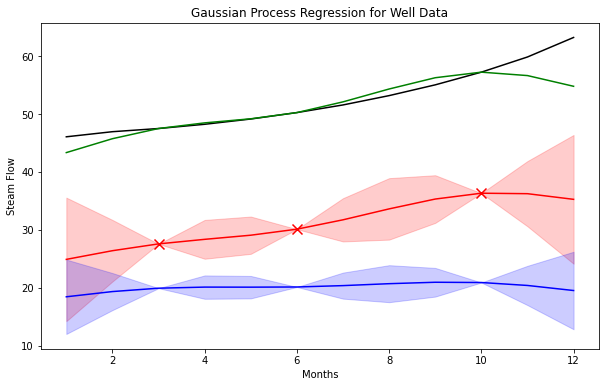

In [42]:
# Plotting
plt.figure(figsize=(10, 6))

# Plot total steam flow data
plt.plot(X, total_steam, color='black', label='Total Steam Flow')

# Plot well 3 predictions with uncertainty interval
plt.plot(X, mean_pred_3, color='red', label='Well 3 Prediction')
plt.fill_between(X.flatten(), mean_pred_3 - 1.96*std_pred_3, mean_pred_3 + 1.96*std_pred_3, color='red', alpha=0.2, label='Well 3 Uncertainty')

# Plot well 9 predictions with uncertainty interval
plt.plot(X, mean_pred_9, color='blue', label='Well 9 Prediction')
plt.fill_between(X.flatten(), mean_pred_9 - 1.96*std_pred_9, mean_pred_9 + 1.96*std_pred_9, color='blue', alpha=0.2, label='Well 9 Uncertainty')

plt.plot(X, mean_pred_3 + mean_pred_9, color='green', label='Summative total')

# Plot training data points for well 3
plt.scatter(wells_data[3]['months'][wells_data[3]['training_indices']], wells_data[3]['y'][wells_data[3]['training_indices']], color='red', marker='x', s=100, label='Well 3 Training Data')

# Plot training data points for well 9
plt.scatter(wells_data[9]['months'][wells_data[9]['training_indices']], wells_data[9]['y'][wells_data[9]['training_indices']], color='blue', marker='o', s=100, label='Well 9 Training Data')

plt.xlabel('Months')
plt.ylabel('Steam Flow')
# plt.legend()
plt.title('Gaussian Process Regression for Well Data')
plt.show()

C:\Users\micha\anaconda3\lib\site-packages\sklearn\gaussian_process\kernels.py:411: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified upper bound 10.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn("The optimal value found for "
C:\Users\micha\anaconda3\lib\site-packages\sklearn\gaussian_process\kernels.py:411: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified upper bound 10.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn("The optimal value found for "


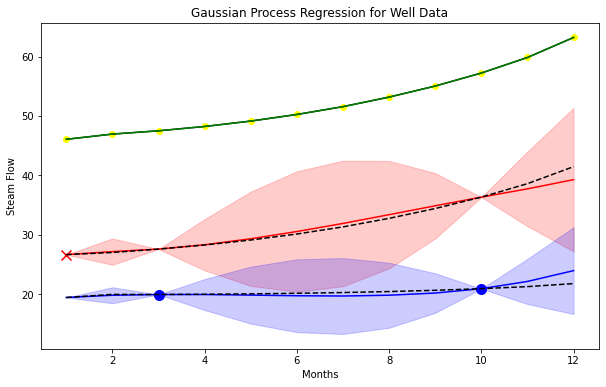

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern

def GPR_Model(X, y_target_well, TI_target_well, y_other_well, TI_other_well, total_steam, LS_bounds=(1e-1, 10), nu=1.5, alpha=1e-10):
    """
    Fits a Gaussian Process Regressor on data and returns the mean and standard deviation of predictions
    :param X: 1D vector containing the x values of observed data (e.g. months)
    :param y_target_well: 1D vector containing the y values of observed data for the target well (e.g. steam flow)
    :param TI_target_well: The training indices of observations to train on for the target well.
    :param y_other_well: 1D vector containing the y values of observed data for other wells
    :param TI_other_well: The training indices of observations to train on for other wells.
    :param LS_bounds: Length scale bounds for the Matern kernel
    :param nu: Parameter for the Matern kernel
    :param alpha: Regularization parameter for GaussianProcessRegressor
    :return: mean_prediction, std_prediction
    """
    X_train, y_train = X[TI_target_well], y_target_well[TI_target_well]

    kernel = 1 * Matern(length_scale_bounds=LS_bounds, nu=nu)
    gaussian_process = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=10, alpha=alpha)

    y_additional = []
    X_additional = []
    for i in range(len(y_other_well)):
        if i in TI_other_well:
            y_additional.append(total_steam[i] - y_other_well[i])
            X_additional.append(i + 1)

    # Convert additional data lists to numpy arrays
    y_additional = np.array(y_additional)
    X_additional = np.array(X_additional).reshape(-1, 1)

    # Combine the original training data with the additional data
    X_train = np.concatenate([X_train.reshape(-1, 1), X_additional])
    y_train = np.concatenate([y_train, y_additional])

    # Fit the Gaussian Process model
    gaussian_process.fit(X_train, y_train)

    # Make predictions
    mean_prediction, std_prediction = gaussian_process.predict(X.reshape(-1, 1), return_std=True)

    return mean_prediction, std_prediction

# Define wells data
wells_data = {
    9: {
        'months': np.linspace(start=1, stop=12, num=12).reshape(-1, 1),
        'y': np.array([19.42, 19.94, 19.92, 19.96, 20.03, 20.13, 20.25, 20.42, 20.63, 20.9, 21.25, 21.76]),
        'training_indices': np.array([2,9]),
        'color': 'blue'
    },
    3: {
        'months': np.linspace(start=1, stop=12, num=12).reshape(-1, 1),
        'y': np.array([26.64, 27, 27.57, 28.26, 29.1, 30.11, 31.31, 32.75, 34.4, 36.32, 38.59, 41.45]),
        'training_indices': np.array([0]),
        'color': 'red'
    }
}

# Total steam flow data
total_steam_flow = {
    'months': np.linspace(start=1, stop=12, num=12).reshape(-1, 1),
    'y': np.array([46.06, 46.94, 47.49, 48.22, 49.13, 50.24, 51.56, 53.17, 55.03, 57.22, 59.84, 63.21])
}

X = total_steam_flow['months']
total_steam = total_steam_flow['y']

# Predict for well 3
y_target_well = wells_data[3]['y']
TI_target_well = wells_data[3]['training_indices']
y_other_well = wells_data[9]['y']
TI_other_well = wells_data[9]['training_indices']
mean_pred_3, std_pred_3 = GPR_Model(X, y_target_well, TI_target_well, y_other_well, TI_other_well, total_steam)

# Predict for well 9
y_target_well = wells_data[9]['y']
TI_target_well = wells_data[9]['training_indices']
y_other_well = wells_data[3]['y']
TI_other_well = wells_data[3]['training_indices']
mean_pred_9, std_pred_9 = GPR_Model(X, y_target_well, TI_target_well, y_other_well, TI_other_well, total_steam)

# Adjust predictions to match total steam flow
mean_sum = mean_pred_3 + mean_pred_9
adjustment_factor = total_steam - mean_sum
mean_pred_3_adjusted = mean_pred_3 + adjustment_factor / 2
mean_pred_9_adjusted = mean_pred_9 + adjustment_factor / 2

# Plotting
plt.figure(figsize=(10, 6))

# Plot total steam flow data
plt.plot(X, total_steam, color='black', label='Total Steam Flow')

# Plot well 3 predictions with uncertainty interval
plt.plot(X, mean_pred_3_adjusted, color='red', label='Well 3 Prediction')
plt.fill_between(X.flatten(), mean_pred_3_adjusted - 1.96*std_pred_3, mean_pred_3_adjusted + 1.96*std_pred_3, color='red', alpha=0.2, label='Well 3 Uncertainty')

# Plot well 9 predictions with uncertainty interval
plt.plot(X, mean_pred_9_adjusted, color='blue', label='Well 9 Prediction')
plt.fill_between(X.flatten(), mean_pred_9_adjusted - 1.96*std_pred_9, mean_pred_9_adjusted + 1.96*std_pred_9, color='blue', alpha=0.2, label='Well 9 Uncertainty')

# Plot summative total prediction
plt.plot(X, mean_pred_3_adjusted + mean_pred_9_adjusted, color='green', label='Summative Total')

# Plot training data points for well 3
plt.plot(wells_data[3]['months'], wells_data[3]['y'], color="black", linestyle="--")
plt.scatter(wells_data[3]['months'][wells_data[3]['training_indices']], wells_data[3]['y'][wells_data[3]['training_indices']], color='red', marker='x', s=100, label='Well 3 Training Data')

# Plot training data points for well 9
plt.plot(wells_data[9]['months'], wells_data[9]['y'], color="black", linestyle="--")
plt.scatter(wells_data[9]['months'][wells_data[9]['training_indices']], wells_data[9]['y'][wells_data[9]['training_indices']], color='blue', marker='o', s=100, label='Well 9 Training Data')

plt.scatter(X, mean_pred_3_adjusted+mean_pred_9_adjusted, color="yellow")

plt.xlabel('Months')
plt.ylabel('Steam Flow')
# plt.legend()
plt.title('Gaussian Process Regression for Well Data')
plt.show()
